<hr>
<h1 style="text-align: center;">Source Panel Method</h1>
<hr>

<h3 style="text-align: center;">Ephraim Aung</h3>
<h3 style="text-align: center;">Student ID: 920074048</h3>
<h3 style="text-align: center;">Project #: 3</h3>
<h3 style="text-align: center;">Date:11/6/2024 </h3>

<h3 style="text-align: center;">EAE 127: Applied Aerodynamics</h3>
<h3 style="text-align: center;">University of California, Davis</h3>

<hr>

Setup

In [183]:
import math
import pyxfoil
import numpy as np
import matplotlib.pyplot as plt

from scipy import integrate

#STANDARD IMPORTS
import os
### JUPYTER NOTEBOOK SETTINGS ########################################
#Plot all figures in full-size cells, no scroll bars
%matplotlib inline
#Disable Python Warning Output
#(NOTE: Only for production, comment out for debugging)
import warnings
warnings.filterwarnings('ignore')
### PLOTTING DEFAULTS BOILERPLATE (OPTIONAL) #########################
#SET DEFAULT FIGURE APPERANCE
import seaborn as sns #Fancy plotting package
#No Background fill, legend font scale, frame on legend
sns.set(style='whitegrid', font_scale=1.5, rc={'legend.frameon': True})
#Mark ticks with border on all four sides (overrides 'whitegrid')
sns.set_style('ticks')
#ticks point in
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#fix invisible marker bug
sns.set_context(rc={'lines.markeredgewidth': 0.1})
#restore default matplotlib colormap
mplcolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(mplcolors)

#Get color cycle for manual colors
colors = sns.color_palette()
#SET MATPLOTLIB DEFAULTS
#(call after seaborn, which changes some defaults)
params = {
#FONT SIZES
'axes.labelsize' : 30, #Axis Labels
'axes.titlesize' : 30, #Title
'font.size' : 28, #Textbox
'xtick.labelsize': 22, #Axis tick labels
'ytick.labelsize': 22, #Axis tick labels
'legend.fontsize': 24, #Legend font size
'font.family' : 'serif',
'font.fantasy' : 'xkcd',
'font.sans-serif': 'Helvetica',
'font.monospace' : 'Courier',
#AXIS PROPERTIES
'axes.titlepad' : 2*6.0, #title spacing from axis
'axes.grid' : True, #grid on plot
'figure.figsize' : (8,8), #square plots
'savefig.bbox' : 'tight', #reduce whitespace in saved figures
#LEGEND PROPERTIES
'legend.framealpha' : 0.5,
'legend.fancybox' : True,
'legend.frameon' : True,
'legend.numpoints' : 1,
'legend.scatterpoints' : 1,
'legend.borderpad' : 0.1,
'legend.borderaxespad' : 0.1,
'legend.handletextpad' : 0.2,
'legend.handlelength' : 1.0,
'legend.labelspacing' : 0,
}
import matplotlib
matplotlib.rcParams.update(params) #update matplotlib defaults, call after￿
### END OF BOILERPLATE ##################################################
colors = sns.color_palette() #color cycle

In [184]:
class Panel:
    def __init__(self, xa, ya, xb, yb):
        self.xa, self.ya = xa, ya
        self.xb, self.yb = xb, yb
        
        self.xc, self.yc = (xa + xb) / 2, (ya + yb) / 2
        self.length = math.sqrt((xb - xa)**2 + (yb - ya)**2)
        
        if xb - xa <= 0:
            self.beta = math.acos((yb - ya) / self.length)
        elif xb - xa > 0:
            self.beta = math.pi + math.acos(-(yb - ya) / self.length)
            
        if self.beta <= math.pi:
            self.loc = 'upper'
        else:
            self.loc = 'lower'
            
        self.theta = math.atan2(self.yc, self.xc)
        
        self.signma = 0.0
        self.vt = 0.0
        self.cp = 0.0


In [185]:
        
N_panels1 = 10          
R1 = 0.75
x_circle1 = R1 * np.cos(np.linspace(0.0, 2 * math.pi, 100))
y_circle1 = R1 * np.sin(np.linspace(0.0, 2 * math.pi, 100))

x_points1 = R1 * np.cos(np.linspace(0.0, 2 * math.pi, N_panels1 + 1))
y_points1 = R1 * np.sin(np.linspace(0.0, 2 * math.pi, N_panels1 + 1))

cylinder_panels1 = np.empty(N_panels1, dtype = object)     

for i in range(N_panels1):
    cylinder_panels1[i] = Panel(x_points1[i], y_points1[i], x_points1[i+1], y_points1[i+1])
    
    
N_panels2 = 40          
R2 = 0.75
x_circle2 = R2 * np.cos(np.linspace(0.0, 2 * math.pi, 100))
y_circle2 = R2 * np.sin(np.linspace(0.0, 2 * math.pi, 100))

x_points2 = R2 * np.cos(np.linspace(0.0, 2 * math.pi, N_panels2 + 1))
y_points2 = R2 * np.sin(np.linspace(0.0, 2 * math.pi, N_panels2 + 1))

cylinder_panels2 = np.empty(N_panels2, dtype=object)     

for i in range(N_panels2):
    cylinder_panels2[i] = Panel(x_points2[i], y_points2[i], x_points2[i+1], y_points2[i+1])
    
N_panels3 = 160          
R3 = 0.75
x_circle3 = R3 * np.cos(np.linspace(0.0, 2 * math.pi, 100))
y_circle3 = R3 * np.sin(np.linspace(0.0, 2 * math.pi, 100))

x_points3 = R3 * np.cos(np.linspace(0.0, 2 * math.pi, N_panels3 + 1))
y_points3 = R3 * np.sin(np.linspace(0.0, 2 * math.pi, N_panels3 + 1))

cylinder_panels3 = np.empty(N_panels3, dtype=object)     

for i in range(N_panels3):
    cylinder_panels3[i] = Panel(x_points3[i], y_points3[i], x_points3[i+1], y_points3[i+1])

1.0 Source Panel Method

In [186]:
def integral_normal(p_i, p_j):

    def integrand(s):
        return (((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s)) * math.cos(p_i.beta) +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s)) * math.sin(p_i.beta)) /
                ((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s))**2 +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s))**2))
    return integrate.quad(integrand, 0.0, p_j.length)[0]

def integral_tangential(p_i, p_j):

    def integrand(s):
        return ((-(p_i.xc - (p_j.xa - math.sin(p_j.beta) * s)) * math.sin(p_i.beta) +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s)) * math.cos(p_i.beta)) /
                ((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s))**2 +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s))**2))
    return integrate.quad(integrand, 0.0, p_j.length)[0]
        

def analyze_panels(panels, u_inf):
    
    Num = len(panels)

    #Normal Velocity Calculations
    A_n = np.empty((Num, Num), dtype = float)
    np.fill_diagonal(A_n, 0.5)
      
    # Create the source influence matrix [A] of the linear system  
    for i, p_i in enumerate(panels):
        for j, p_j in enumerate(panels):
            if i != j:
                A_n[i,j] = (0.5/math.pi) * integral_normal(p_i, p_j)

    # Create the right hand side [b] of the linear system
    b_n = - u_inf * np.cos([p.beta for p in panels])

    sigma = np.linalg.solve(A_n,b_n)

    for i, panel in enumerate(panels):
        panel.sigma = sigma[i]

    # ====================================================================== #
    # Tangential Velocity Calculations
    A_t = np.empty((Num, Num), dtype = float)
    np.fill_diagonal(A_t, 0.0)


    # Create the source influence matrix [A] of the linear system
    for i, p_i in enumerate(panels):
        for j, p_j in enumerate(panels):
            if i!=j:
                A_t[i,j] = (0.5 / math.pi) * integral_tangential(p_i, p_j)

    # Create the right hand side [b] of the linear system
    b_t = -u_inf * np.sin([p.beta for p in panels])
    vt = np.dot(A_t, sigma) + b_t

    for i, panel in enumerate(panels):
        panel.vt = vt[i]
    
    # Tangential Velocity to calculate surface pressure Cp:
    for panel in panels:
        panel.cp = 1.0 - (panel.vt/u_inf)**2

    print('Panel Analysis Complete!')
   


Discussion:
The Panel class discretizes a body into smaller segments (panels). Each panel represents a portion of the body's surface and has properties such as its endpoints, center, length, and orientation angle (beta). This function also stores values. such as vt, cp, and sigma. These values are used in the integration portion.

The integral_normal function calculates the normal velocities of each panel's effect on each other. The integral_tangential function calculates the tangential velocities of each panel's effect on each other. Both of these functions create and store matrices.

These matrices are solved in the analyze_panels function which outputs the source strengths, Cp, and tangential velocities.


2.0 Flow Over a Non-Rotating Cylinder

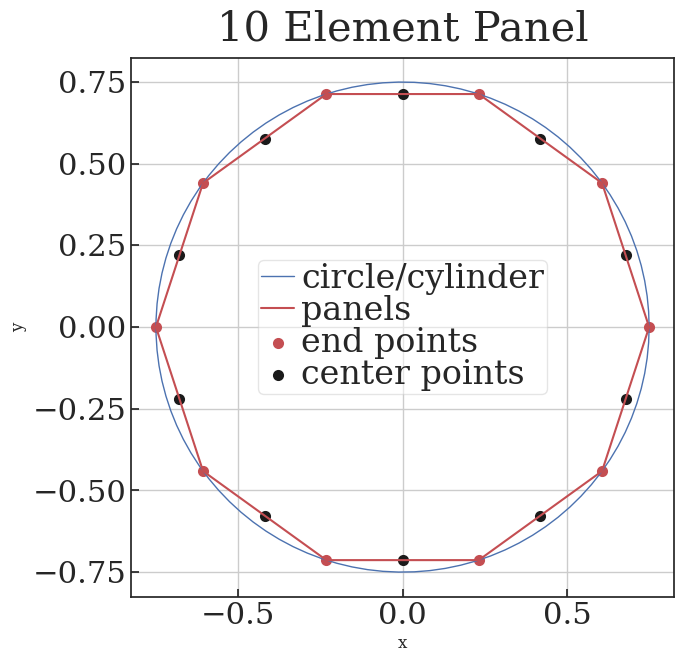

Panel Analysis Complete!


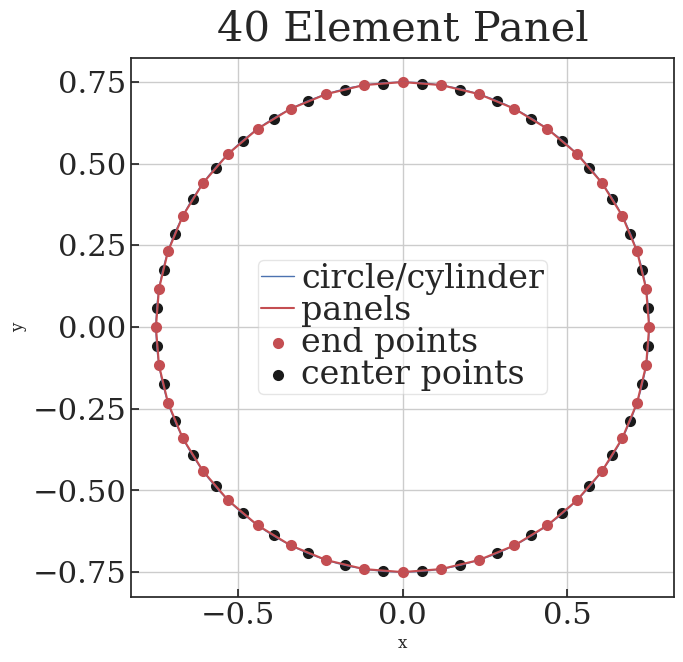

Panel Analysis Complete!


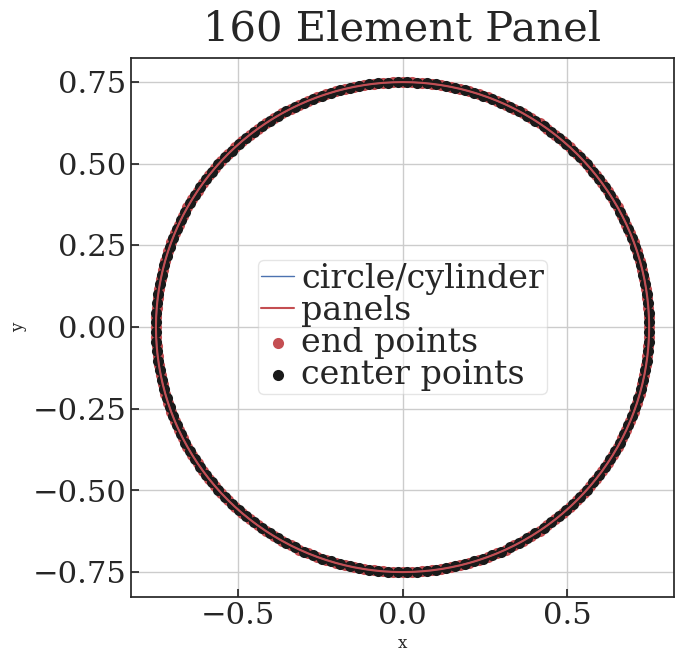

Panel Analysis Complete!


In [187]:
#1

plt.figure(figsize=(7,7))
plt.grid(True)
plt.xlabel('x', fontsize = 12)
plt.ylabel('y', fontsize = 12)
plt.title('10 Element Panel')
plt.plot(x_circle1, y_circle1, label = 'circle/cylinder', color = 'b', linewidth = 1)
# Plotting our circle/the geometry we would like to discretize

plt.plot(x_points1, y_points1, label = 'panels', color = 'r')
# Plotting our end points / panels

plt.scatter([p.xa for p in cylinder_panels1], [p.ya for p in cylinder_panels1], label = 'end points', color = 'r', linewidth = 2)
# This code may look a little bit odd to you. The code within the brackets accesses the information 
# inside of the variable 'cylinder_panels'. For each panel inside of 'cylinder_panels', we plot 
# the xa and ya variables associated with those panels.

plt.scatter([p.xc for p in cylinder_panels1], [p.yc for p in cylinder_panels1], label = 'center points', color = 'k', linewidth = 2)
# The same is done here as above, except we use the center points instead of the end points.
# Using the code here we can access any of the information within a specific Panel object. 

plt.legend(loc = 'best')
plt.show()

U_infty = 1.0

analyze_panels(cylinder_panels1, U_infty)

#2

plt.figure(figsize=(7,7))
plt.grid(True)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('40 Element Panel')
plt.plot(x_circle2, y_circle2, label='circle/cylinder', color='b', linewidth=1)
# Plotting our circle/the geometry we would like to discretize

plt.plot(x_points2, y_points2, label='panels', color='r')
# Plotting our end points / panels

plt.scatter([p.xa for p in cylinder_panels2], [p.ya for p in cylinder_panels2], label='end points', color='r', linewidth=2)
# Plotting the xa and ya variables associated with those panels.

plt.scatter([p.xc for p in cylinder_panels2], [p.yc for p in cylinder_panels2], label='center points', color='k', linewidth=2)
# Plotting the center points instead of the end points.

plt.legend(loc='best')
plt.show()


analyze_panels(cylinder_panels2, U_infty)

#3

plt.figure(figsize=(7,7))
plt.grid(True)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('160 Element Panel')
plt.plot(x_circle3, y_circle3, label='circle/cylinder', color='b', linewidth=1)
# Plotting our circle/the geometry we would like to discretize

plt.plot(x_points3, y_points3, label='panels', color='r')
# Plotting our end points / panels

plt.scatter([p.xa for p in cylinder_panels3], [p.ya for p in cylinder_panels3], label='end points', color='r', linewidth=2)
# Plotting the xa and ya variables associated with those panels.

plt.scatter([p.xc for p in cylinder_panels3], [p.yc for p in cylinder_panels3], label='center points', color='k', linewidth=2)
# Plotting the center points instead of the end points.

plt.legend(loc='best')
plt.show()


analyze_panels(cylinder_panels3, U_infty)



100
100
100


(-4.0, 2.0)

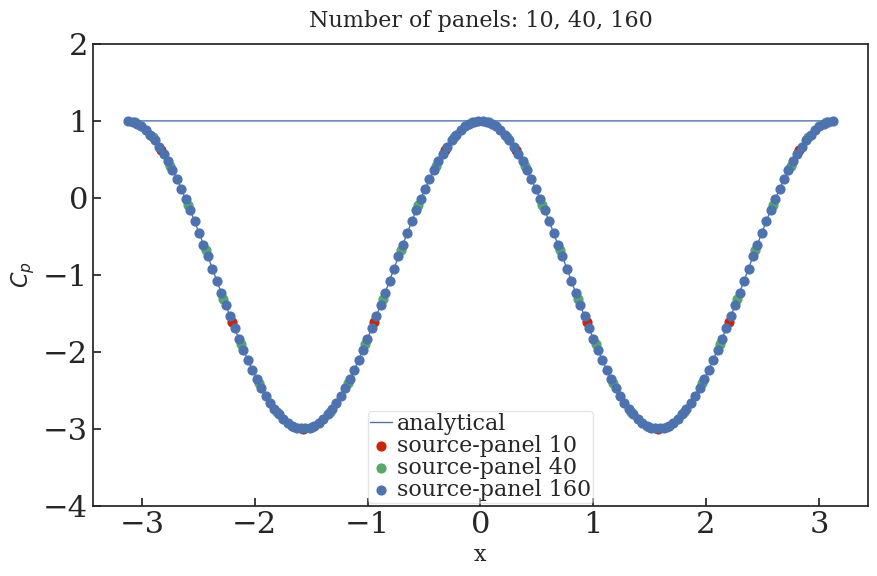

In [188]:
#1

length1 = (len(x_circle1))
theta1 = np.zeros((length1, 1))

for i in range(0, length1):
    theta1[i] = math.atan2(y_circle1[i], x_circle1[i])

# print(theta)

cp_analytical1 = 1.0 - 4 * (y_circle1 / R1)**2

print(len(theta1))

# plot the surface pressure coefficient
plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('x', fontsize=16)
plt.ylabel('$C_p$', fontsize=16)

plt.plot(theta1, cp_analytical1,
            label='analytical',
            color='b', linestyle='-', linewidth=1, zorder=1)

plt.scatter([p.theta for p in cylinder_panels1], [p.cp for p in cylinder_panels1],
               label='source-panel 10',
               color='#CD2305', s=40, zorder=2)

plt.ylim(-4.0, 2.0)


#2

length2 = (len(x_circle2))
theta2 = np.zeros((length2, 1))

for i in range(0, length2):
    theta2[i] = math.atan2(y_circle2[i], x_circle2[i])

# print(theta)

cp_analytical2 = 1.0 - 4 * (y_circle2 / R2)**2

print(len(theta2))

# plot the surface pressure coefficient


plt.scatter([p.theta for p in cylinder_panels2], [p.cp for p in cylinder_panels2],
               label='source-panel 40',
               color='g', s=40, zorder=2)

plt.ylim(-4.0, 2.0)


#3


length3 = (len(x_circle3))
theta3 = np.zeros((length3, 1))

for i in range(0, length3):
    theta3[i] = math.atan2(y_circle3[i], x_circle3[i])

# print(theta)

cp_analytical3 = 1.0 - 4 * (y_circle3 / R3)**2

print(len(theta3))

# plot the surface pressure coefficient


plt.scatter([p.theta for p in cylinder_panels3], [p.cp for p in cylinder_panels3],
               label='source-panel 160',
               color='b', s=40, zorder=2)

plt.title(f'Number of panels: {N_panels1}, {N_panels2}, {N_panels3}', fontsize=16)
plt.legend(loc='best', prop={'size':16})

plt.ylim(-4.0, 2.0)

In [189]:
import numpy as np

# Function to compute error between analytical and panel method
def compute_error(theta_analytical, cp_analytical, theta_panel, cp_panel):
    # Integrate using trapezoidal rule for both analytical and panel Cp distributions
    integral_analytical = np.trapz(cp_analytical, theta_analytical)
    integral_panel = np.trapz(cp_panel, theta_panel)
    
    # Calculate absolute error
    error = abs(integral_analytical - integral_panel)
    
    return error

# Analytical Cp calculation (already done in your code)
cp_analytical1 = 1.0 - 4 * (y_circle1 / R1)**2
cp_analytical2 = 1.0 - 4 * (y_circle2 / R2)**2
cp_analytical3 = 1.0 - 4 * (y_circle3 / R3)**2

# Calculate errors for each panel size
error1 = compute_error(theta1.flatten(), cp_analytical1, [p.theta for p in cylinder_panels1], [p.cp for p in cylinder_panels1])
error2 = compute_error(theta2.flatten(), cp_analytical2, [p.theta for p in cylinder_panels2], [p.cp for p in cylinder_panels2])
error3 = compute_error(theta3.flatten(), cp_analytical3, [p.theta for p in cylinder_panels3], [p.cp for p in cylinder_panels3])

# Print errors
print(f"Error for N_panels1 (10 panels): {error1}")
print(f"Error for N_panels2 (40 panels): {error2}")
print(f"Error for N_panels3 (160 panels): {error3}")

Error for N_panels1 (10 panels): 1.9863408523626518
Error for N_panels2 (40 panels): 0.02379910546715891
Error for N_panels3 (160 panels): 0.054821310109405275


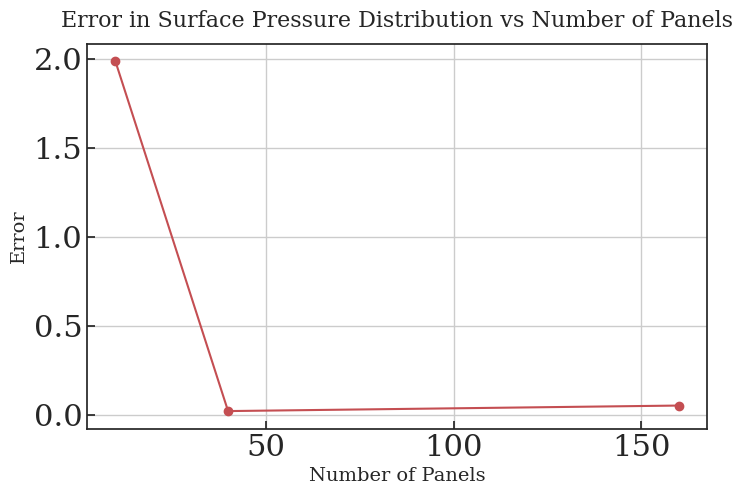

In [190]:
# Panel sizes and corresponding errors
panel_sizes = [10, 40, 160]
errors = [error1, error2, error3]

# Plotting error vs. panel size
plt.figure(figsize=(8,5))
plt.plot(panel_sizes, errors, marker='o', linestyle='-', color='r')
plt.xlabel('Number of Panels', fontsize=14)
plt.ylabel('Error', fontsize=14)
plt.title('Error in Surface Pressure Distribution vs Number of Panels', fontsize=16)
plt.grid(True)
plt.show()

Discussion: It can be observed that the accuracy improves as the number of panels increases. However, an unexpected result came up which is showing a slighly increased error going from 40 to 160 panels. It is an error that I assume is from some sort of trunkation or error from the trapazoidal numerical integration method.

3.0 Symmetric and Cambered Airfoil Panel Methods

0
0
1
0
2
1
3
3
4
5
5
7
6
9
7
11
8
14
9
17
10
20
11
24
12
27
13
31
14
34
15
38
16
41
17
44
18
48
19
51
20
54
21
57
22
62
23
67
24
73
25
78
26
85
27
91
28
96
29
101
30
104
31
107
32
110
33
114
34
117
35
120
36
124
37
127
38
131
39
134
40
138
41
141
42
144
43
147
44
149
45
151
46
153
47
155
48
157
49
158


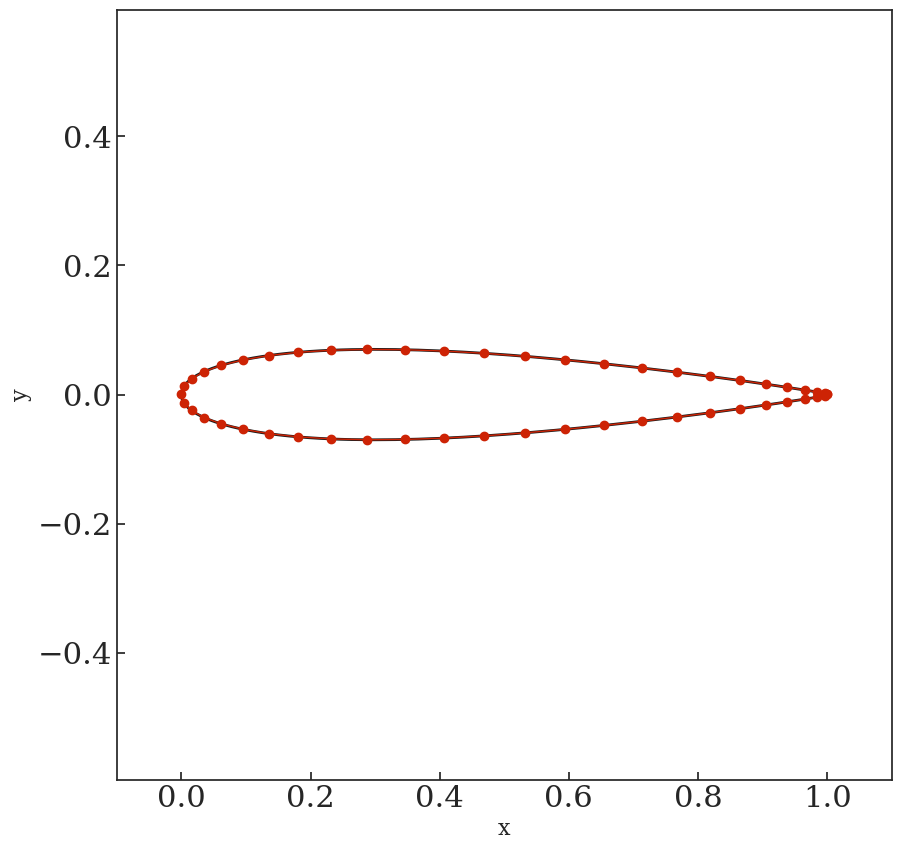

Panel Analysis Complete!


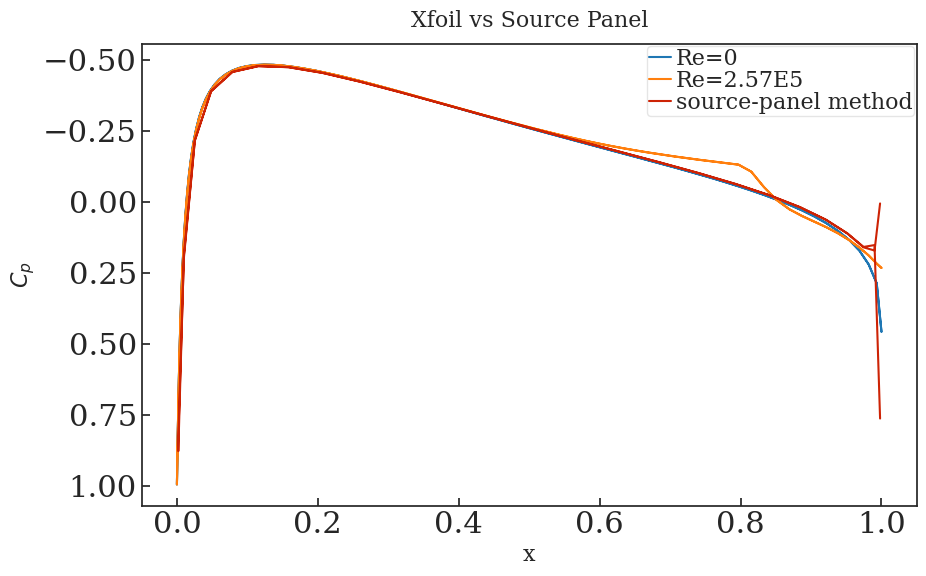

In [191]:
def define_panels(x, y, N=40):
   
    R = (x.max() - x.min()) / 2                 # Radius of the circle, based on airfoil geometry
    x_center = (x.max() + x.min()) / 2          # X coordinate of center of circle


    x_circle = x_center + R * np.cos(np.linspace(0.0, 2 * math.pi, N + 1))
    # Here we define the x coordinates of the circle
    
    x_ends = np.copy(x_circle)                  # projection of the x-coord on the surface
    y_ends = np.empty_like(x_ends)              # initialization of the y-coord Numpy array

    x, y = np.append(x, x[0]), np.append(y, y[0])  # extend arrays using numpy.append
    
    # computes the y-coordinate of end-points
    I = 0
    for i in range(N):
        while I < len(x) - 1:
            if (x[I] <= x_ends[i] <= x[I + 1]) or (x[I + 1] <= x_ends[i] <= x[I]):
                break
            else:
                I += 1
        a = (y[I + 1] - y[I]) / (x[I + 1] - x[I])
        b = y[I + 1] - a * x[I + 1]
        y_ends[i] = a * x_ends[i] + b
        print(i)
        print(I)
    y_ends[N] = y_ends[0]
    
    panels = np.empty(N, dtype=object)
    for i in range(N):
        panels[i] = Panel(x_ends[i], y_ends[i], x_ends[i + 1], y_ends[i + 1])
    
    return panels


# Testing source panel method using a symmetric airfoil at zero angle of attack
naca = True
alf = 0
foil = '0014'
Re = 2.57E5
#Re = 0
pyxfoil.GetPolar(foil, naca, alf, Re)

filename = 'Data/naca0014/naca0014.dat'
x, y = np.loadtxt(filename, dtype=float, unpack=True, skiprows = 1)

N = 50
panels = define_panels(x,y,N)




# plot the geometry and the panels
width = 10
plt.figure(figsize=(width, width))
plt.grid()
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.plot(x, y, color='k', linestyle='-', linewidth=2)
plt.plot(np.append([panel.xa for panel in panels], panels[0].xa),
            np.append([panel.ya for panel in panels], panels[0].ya),
            linestyle='-', linewidth=1, marker='o', markersize=6, color='#CD2305')
plt.axis('equal')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 0.1)
plt.show()


# Analysis using xfoil 
filename = 'Data/naca0014/naca0014_surfCP_Re2.57e+05a0.0.dat'
x142,y142,Cp142 = np.loadtxt(filename, unpack = True, skiprows = 3)

# Analysis using xfoil 
filename = 'Data/naca0014/naca0014_surfCP_Re0.00e+00a0.0.dat'
x141,y141,Cp141 = np.loadtxt(filename, unpack = True, skiprows = 3)

U_infty = 5
analyze_panels(panels, U_infty)

plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('x', fontsize=16)
plt.ylabel('$C_p$', fontsize=16)
plt.plot(x141, Cp141,label='Re=0')
plt.plot(x142, Cp142,label='Re=2.57E5')
plt.gca().invert_yaxis()

plt.plot([p.xc for p in panels], [p.cp for p in panels],
               label='source-panel method',
               color='#CD2305')

plt.title('Xfoil vs Source Panel', fontsize=16)
plt.legend(loc='best', prop={'size':16})
plt.show()



0
0
1
0
2
1
3
3
4
5
5
7
6
9
7
12
8
14
9
18
10
21
11
24
12
28
13
31
14
35
15
39
16
42
17
46
18
49
19
52
20
55
21
59
22
63
23
68
24
74
25
80
26
87
27
92
28
98
29
102
30
106
31
109
32
112
33
115
34
118
35
121
36
124
37
128
38
131
39
135
40
138
41
141
42
144
43
147
44
149
45
152
46
154
47
155
48
157
49
158


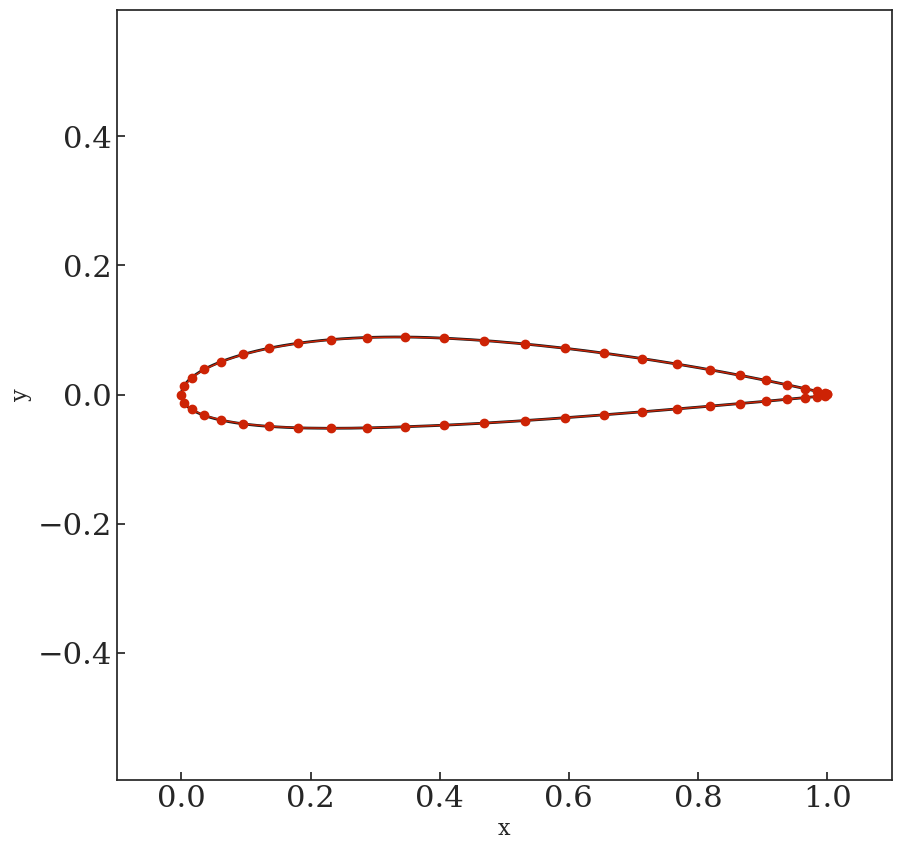

Panel Analysis Complete!


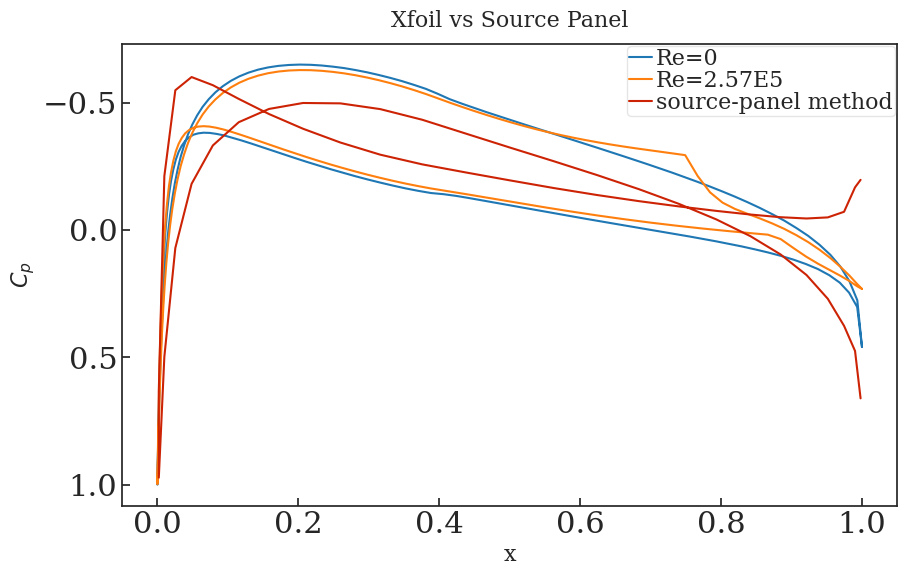

In [192]:
naca = True
alf = 0
foil = '2414'
Re = 2.57E5
#Re = 0 
pyxfoil.GetPolar(foil, naca, alf, Re)

filename = 'Data/naca2414/naca2414.dat'
x, y = np.loadtxt(filename, dtype=float, unpack=True, skiprows = 1)

N = 50
panels = define_panels(x,y,N)

# plot the geometry and the panels
width = 10
plt.figure(figsize=(width, width))
plt.grid()
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.plot(x, y, color='k', linestyle='-', linewidth=2)
plt.plot(np.append([panel.xa for panel in panels], panels[0].xa),
            np.append([panel.ya for panel in panels], panels[0].ya),
            linestyle='-', linewidth=1, marker='o', markersize=6, color='#CD2305')
plt.axis('equal')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 0.1)
plt.show()
# Creating panels works well

# Analysis using xfoil 
filename = 'Data/naca2414/naca2414_surfCP_Re2.57e+05a0.0.dat'
x144,y144,Cp144 = np.loadtxt(filename, unpack = True, skiprows = 3)

filename = 'Data/naca2414/naca2414_surfCP_Re0.00e+00a0.0.dat'
x143,y143,Cp143 = np.loadtxt(filename, unpack = True, skiprows = 3)

U_infty = 5
analyze_panels(panels, U_infty)

plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('x', fontsize=16)
plt.ylabel('$C_p$', fontsize=16)
plt.plot(x143, Cp143,label='Re=0')
plt.plot(x144, Cp144,label='Re=2.57E5')
plt.gca().invert_yaxis()

plt.plot([p.xc for p in panels], [p.cp for p in panels],
               label='source-panel method',
               color='#CD2305')

plt.title('Xfoil vs Source Panel', fontsize=16)
plt.legend(loc='best', prop={'size':16})
plt.show()

Analysis Question: 
Compare the accuracy of your source panel method for a symmetric airfoil. Do the results seem to agree with XFOIL? 
    For this method, the ouputs are nearly identical except near the end where the pressures both aggressively diverge for the source panel method. For the other methods, the divergence is not nearly as aggressive. 

When you repeat the analysis with a cambered airfoil, how does the accuracy change? 
    For the most part, the results seem to be comperarable. However, some key differences can be seen on the front and rear of the airfoil. At the rear specifically, you can see that the one of the surfaces of the source panel methods diverges by going upwards while the rest of the pack trends downward. Throughout the midpoints of the airfoil, the slopes are the same while having vertical translations compared to each other.

Explain what is occurring between the two different types of airfoils? 
    It is likely that there is more error for the cambered airfoil because the panel method we have is not a very high fidelity model compared to the xfoil panel method. Additionally, cambered airfoils have more intricacy in their shape which directely correlates to the value outputs. Because of this, each panel that is created has some error that strays the values farther from the original. This is likely why the cambered airfoil see's more error than the symmetric.

What are some limitations of the source panel method based on these results, what steps could be taken to improve our panel method? 
    Some limitations of the source panel method are likely that there are no sinks and that the accuracy will be determined by the processing power and code efficiency of the user. Additionally, this method operates under the assumption of incompressible and irrotational flow which is very very rare in real life. Therefore, processes that can simulate those conditions are areas where this method can improve.


In [193]:

# Define function to compute aerodynamic coefficients
def compute_coefficients(panels, U_inf):
    cl, cd = 0.0, 0.0
    for panel in panels:
        delta_x = panel.xb - panel.xa
        delta_y = panel.yb - panel.ya
        cl += -panel.cp * delta_x / U_inf
        cd += -panel.cp * delta_y / U_inf
    return cl, cd

# Initialize parameters
U_inf = 5.0
panel_counts = [11, 14, 20, 30, 44, 60, 90, 140, 200]
cl_values, cd_values = [], []

# Loop over panel counts, analyze, and compute coefficients
for N in panel_counts:
    panels = define_panels(x, y, N)  # Define panels
    analyze_panels(panels, U_inf)     # Analyze panel method
    cl, cd = compute_coefficients(panels, U_inf)  # Compute lift and drag
    cl_values.append(cl)
    cd_values.append(cd)

# Load XFOIL data
filename = 'Data/naca0014/naca0014_polar_Re0.00e+00a0.00.dat'
alpha, CL, CD, Cdp, Cm, x_top, x_bot = np.loadtxt(filename, unpack=True, skiprows=12)
cl_values.append(CL)
cd_values.append(CD)
panel_counts.append("XFOIL")

# Print table header
print(f"{'Panels':<10} | {'C_L':>10} | {'C_D':>10}")
print("-" * 34)

# Print table rows
for i in range(len(panel_counts)):
    print(f"{panel_counts[i]:<10} | {cl_values[i]:>10.5f} | {cd_values[i]:>10.5f}")
    
    

0
0
1
6
2
18
3
34
4
49
5
67
6
67
7
111
8
126
9
141
10
153
Panel Analysis Complete!
0
0
1
4
2
12
3
23
4
36
5
48
6
61
7
80
8
100
9
112
10
124
11
136
12
147
13
154
Panel Analysis Complete!
0
0
1
2
2
7
3
13
4
21
5
30
6
39
7
47
8
55
9
66
10
80
11
95
12
106
13
113
14
121
15
130
16
138
17
146
18
152
19
156
Panel Analysis Complete!
0
0
1
1
2
3
3
7
4
11
5
15
6
21
7
27
8
33
9
39
10
44
11
50
12
55
13
62
14
70
15
80
16
90
17
99
18
106
19
111
20
116
21
121
22
127
23
133
24
138
25
143
26
148
27
152
28
155
29
157
Panel Analysis Complete!
0
0
1
0
2
2
3
4
4
6
5
8
6
11
7
14
8
18
9
22
10
26
11
30
12
34
13
38
14
42
15
46
16
49
17
53
18
57
19
61
20
67
21
73
22
80
23
87
24
94
25
100
26
104
27
108
28
111
29
115
30
118
31
122
32
126
33
130
34
134
35
137
36
141
37
144
38
147
39
150
40
153
41
155
42
156
43
158
Panel Analysis Complete!
0
0
1
0
2
1
3
2
4
3
5
5
6
7
7
9
8
11
9
13
10
15
11
18
12
21
13
24
14
27
15
30
16
33
17
36
18
39
19
42
20
44
21
47
22
50
23
53
24
55
25
58
26
62
27
66
28
70
29
75
30
80
31
86
32
90